## HCP individualized connectome prediction evaluation

In [10]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
from sklearn.decomposition import PCA
import torch
from torch.utils.data import Dataset, DataLoader
from data.data_utils import *


In [11]:
# --- Reloadable utility to keep notebook state fresh when editing code ---
import importlib

# --- Data loading and utils (see Conn2Conn/data/) ---
from data.hcp_dataset import HCP_Base, HCP_Partition
import data.hcp_dataset
import data.dataset_utils
import data.data_utils
importlib.reload(data.hcp_dataset)
importlib.reload(data.dataset_utils)
importlib.reload(data.data_utils)
from data.hcp_dataset import *
from data.dataset_utils import *
from data.data_utils import *

# --- Model definitions and core model imports (see Conn2Conn/models/) ---
import models
importlib.reload(models)
from models import *

# --- Evaluation utilities (models/eval.py, models/eval_utils.py, models/loss.py) ---
import models.eval
importlib.reload(models.eval)
from models.eval import *

import models.eval_utils
importlib.reload(models.eval_utils)
from models.eval_utils import *

import models.loss
importlib.reload(models.loss)
from models.loss import *

import main
importlib.reload(main)
from main import *

In [12]:
import importlib

import models.models
import models.config
import models.loss
import models.lightning_module
import main

importlib.reload(models.models)
importlib.reload(models.loss)
importlib.reload(models.lightning_module)
importlib.reload(models.config)
importlib.reload(main)

from main import Sim

## How `CrossModal_PCA_PLS_CovProjector` works

**Idea:** Predict target connectome (e.g. FC) from source (e.g. SC) using a **fixed PCA/PLS backbone** plus an **additive covariate residual** that can be learned.

**Data flow:**
1. **Source encoding:** Per modality, subtract mean and project with fixed PCA loadings → `z_src = concat_i((x_i - μ_i) @ W_enc_i)`.
2. **Base prediction:** `z_base = dropout(z_src) @ W_mid.T` (PLS-style mid layer; can be learned).
3. **Covariate branch:** Each covariate source (e.g. `fs_all`, `fs_volumes`, `covariate_one_hot`) is encoded by a small projector (linear / MLP / embedding), then concatenated and passed through a fusion net → `z_cov = fusion(concat_j(encoder_j(cov_j)))`.
4. **Residual add:** `z_target = z_base + α * z_cov` (α is `cov_residual_scale`, fixed or learned).
5. **Decode:** `y_hat = z_target @ W_dec + μ_target`.

**Config (YAML):** `cov_sources`, `cov_projectors` (per-source `type` and `out_dim`), `cov_fusion` (linear or mlp), `cov_out_dim` (must equal `n_components_pca_target`). The dataset must provide a `cov` dict in each batch with keys matching `cov_sources`; `HCP_Base` gets `cov_sources` and builds `cov_dims` and partition `cov` tensors accordingly.

In [13]:
# --- Setup Sim for CovProjector (same pattern as test_models FS projector) ---
CONN2CONN_DIR = "/scratch/asr655/neuroinformatics/Conn2Conn"
os.chdir(CONN2CONN_DIR)

sim = Sim(
    model_name="CrossModal_PCA_PLS_CovProjector",
    config_path=os.path.join(CONN2CONN_DIR, "models/configs/CrossModal_PCA_PLS_CovProjector.yml"),
    source="SC",
    target="FC",
    config_overrides={
        "data": {"source": "SC", "target": "FC"},
        "model": {
            "n_components_pca_source": 256,
            "n_components_pca_target": 256,
            "n_components_pls": 16,
            "learn_encoder": False,
            "learn_mid": True,
            "learn_decoder": False,
            "dropout": 0.2,
            "cov_fusion": {"type": "mlp", "hidden_dims": [64], "dropout": 0.0},
            "learn_cov_scale": False,
        },
        "trainer": {
            "loss_type": "demeaned_mse",
            "lr": 1e-4,
            "max_epochs": 200,
            "batch_size": 64,
        },
    },
)
print("cov_sources:", sim.base.cov_sources)
print("cov_dims:", sim.base.cov_dims)

/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


cov_sources: ['fs_all', 'fs_volumes', 'covariate_one_hot']
cov_dims: {'fs_all': 199, 'fs_volumes': 16, 'covariate_one_hot_vocab_size': 77}


In [15]:
# --- Build the CovProjector model from config (same as main.py) ---
from models.config import build_model, get_default_config, resolve_source_dependent_config

cfg = sim._merge_config(None)  # merged default + data
cfg = resolve_source_dependent_config(cfg)
model_cfg = cfg["model"].copy()
model_cfg.pop("name")

model = build_model(sim.base, "CrossModal_PCA_PLS_CovProjector", model_cfg)
model.eval()
print("Model params (trainable):", model.get_num_params())

/ext3/miniforge3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


CovProjector init: source_dims={'SC': 256}, target_dim=256, cov_sources=['fs_all', 'fs_volumes', 'covariate_one_hot']
Model params (trainable): 103984


/ext3/miniforge3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /scratch/asr655/neuroinformatics/Conn2Conn/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | N

CovProjector init: source_dims={'SC': 256}, target_dim=256, cov_sources=['fs_all'], use_target_scores_in_projector=True (sanity-check)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



Training complete!


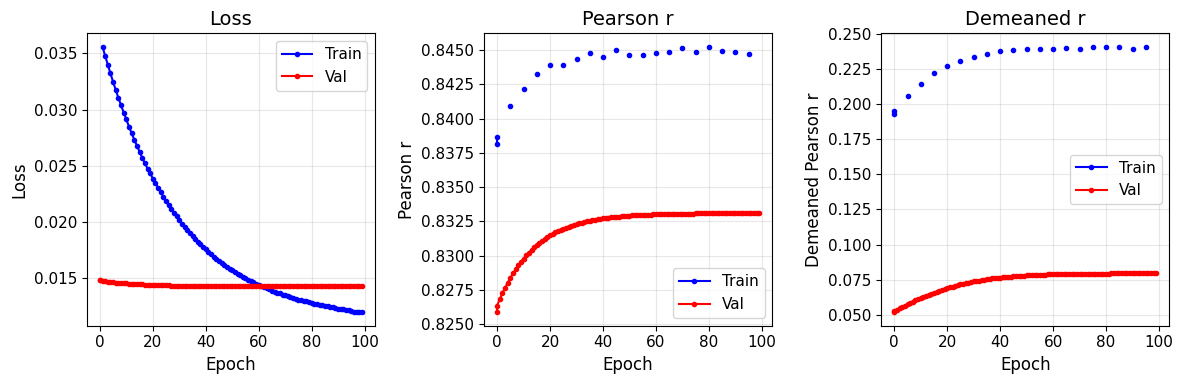

In [ ]:
# Dynamically use only linear fs_all (subset of sim.base cov_sources). No need to recreate Sim.
result = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override={
        "model": {
            "n_components_pca_source": 256,
            "n_components_pca_target": 256,
            "cov_out_dim": 256,
            "n_components_pls": 16,
            "learn_encoder": False,
            "learn_mid": False,
            "learn_decoder": False,
            "dropout": 0.1,
            "cov_sources": ["fs_all"],
            "cov_projectors": {"fs_all": {"type": "linear", "out_dim": 64}},
            "cov_fusion": {"type": "linear"},
            "learn_cov_scale": True,
            "use_target_scores_in_projector": True,
        },
        "trainer": {"max_epochs": 100, "lr": 1e-4, "batch_size": 128}
    },
)
model = result["model"]
if result.get("train_result") is not None:
    result["train_result"].plot()
print("Test metrics:", result.get("test_metrics", {}).get("base_metrics"))